#  Feature Engineering
This notebook constructs meaningful features from raw GPS coordinates
to improve model performance.

Covered steps :

- Amphitheatre centroids computation
- Distance features
- GPS quality features
- Seat zone features
- Temporal features
- Label encoding
- Feature importance preview (mutual information)
- Class imbalance reminder
- Final feature set definition
- Save engineered datasets

## 1.Setup and Imports

In [11]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import json
from pathlib import Path
from sklearn.preprocessing import StandardScaler
from sklearn.feature_selection import mutual_info_classif


PROCESSED = Path('../data/processed')
TARGET_COL = 'target_label'

train = pd.read_csv(PROCESSED / 'train.csv')
val   = pd.read_csv(PROCESSED / 'val.csv')
test  = pd.read_csv(PROCESSED / 'test.csv')

for df in [train, val, test]:
    df['timestamp'] = pd.to_datetime(df['timestamp'], utc=True, errors='coerce')

print(f'train: {train.shape}  val: {val.shape}  test: {test.shape}')
train.dtypes

train: (4664, 25)  val: (999, 25)  test: (1000, 25)


id                                   int64
year                                 int64
section                            float64
user                                object
amphitheatre                        object
module                              object
seat_block                          object
seat_row                           float64
seat_column                        float64
latitude_mean                      float64
longitude_mean                     float64
accuracy_mean                      float64
gps_variance                       float64
is_outside                            bool
sample_count                         int64
raw_gps_readings                    object
collection_metadata                 object
navigator_context                   object
screen_context                      object
network_information                 object
battery_status                      object
timestamp              datetime64[ns, UTC]
created_at                          object
device_info

## 2. Amphitheatre centroids (computed from training set only)

We use the **mean GPS position per amphitheatre in the training set** as reference centroids.
Computing from train only - not from the full dataset - prevents leakage into val/test.

These centroids are then used to compute distance-based features for every sample.

In [12]:
AMPHI_LABELS = [f'Amphi {i}' for i in range(1, 9)]

centroids = (
    train[train[TARGET_COL].isin(AMPHI_LABELS)]
    .groupby(TARGET_COL)[['latitude_mean', 'longitude_mean']]
    .mean()
    .rename(columns={'latitude_mean': 'c_lat', 'longitude_mean': 'c_lon'})
)
print('Centroids (train set):')  
print(centroids.round(6).to_string())

(PROCESSED / 'centroids.json').write_text(
    centroids.reset_index().to_json(orient='records', indent=2)
)

Centroids (train set):
                  c_lat     c_lon
target_label                     
Amphi 1       36.688396  2.866703
Amphi 2       36.688353  2.866493
Amphi 3       36.688389  2.866236
Amphi 4       36.688306  2.866123
Amphi 5       36.688361  2.866690
Amphi 6       36.688351  2.866476
Amphi 7       36.688358  2.866284
Amphi 8       36.688336  2.866116


728

## 3. Distance features

For each sample we compute the **Euclidean distance** (in degrees, fine at this scale) to every
amphitheatre centroid. This gives the model spatial context that raw lat/lon can't express alone.

| Feature | Intuition |
|---|---|
| `dist_Amphi_N` | How far the GPS reading is from each known amphitheatre |
| `dist_nearest` | Distance to the closest amphitheatre |
| `dist_2nd` | Distance to the 2nd closest — gap between 1st and 2nd signals ambiguity |
| `dist_gap` | `dist_2nd − dist_nearest`: large gap = confident placement, small gap = confused |
| `nearest_amphi` | Label of the geometrically closest amphitheatre (may differ from GPS label!) |


> **Why Euclidean and not Haversine?**  
> At this scale (~100 m campus), Euclidean error vs Haversine is < 0.01 m. Not worth the overhead.

In [13]:
def add_distance_features(df, centroids):
    df = df.copy()
    dist_cols = []
    for lbl, row in centroids.iterrows():
        col = f'dist_{lbl.replace(" ", "_")}'
        df[col] = np.sqrt(
            (df['latitude_mean']  - row['c_lat'])**2 +
            (df['longitude_mean'] - row['c_lon'])**2
        )
        dist_cols.append(col)

    dist_matrix = df[dist_cols]
    df['dist_nearest']   = dist_matrix.min(axis=1)
    df['dist_2nd']       = dist_matrix.apply(lambda r: r.nsmallest(2).iloc[-1], axis=1)
    df['dist_gap']       = df['dist_2nd'] - df['dist_nearest']
    df['nearest_amphi']  = dist_matrix.idxmin(axis=1).str.replace('dist_', '').str.replace('_', ' ')
    return df, dist_cols

train, dist_cols = add_distance_features(train, centroids)
val,   _         = add_distance_features(val,   centroids)
test,  _         = add_distance_features(test,  centroids)

print(f'Distance features added: {len(dist_cols)} centroid distances + 4 summary features')
train[dist_cols + ['dist_nearest', 'dist_gap', 'nearest_amphi']].head(5)

Distance features added: 8 centroid distances + 4 summary features


,dist_Amphi_1,dist_Amphi_2,dist_Amphi_3,dist_Amphi_4,dist_Amphi_5,dist_Amphi_6,dist_Amphi_7,dist_Amphi_8,dist_nearest,dist_gap,nearest_amphi
0,0.000598,0.000383,0.000164,0.000032,0.000578,0.000366,0.000186,0.000061,0.000032,0.000029,Amphi 4
1,0.000211,0.000009,0.000266,0.000377,0.000192,0.000023,0.000214,0.000383,0.000009,0.000014,Amphi 2
2,0.000233,0.000021,0.000246,0.000355,0.000214,0.000011,0.000193,0.000361,0.000011,0.000010,Amphi 6
3,0.000204,0.000013,0.000272,0.000384,0.000185,0.000029,0.000221,0.000390,0.000013,0.000016,Amphi 2
4,0.000226,0.000013,0.000247,0.000361,0.000209,0.000006,0.000196,0.000365,0.000006,0.000007,Amphi 6


## 4. GPS quality features

The GPS columns `accuracy_mean` and `gps_variance` are **diagnostic** signals.

**Important:** `gps_variance` is **constant 0** for this entire dataset — it was crushed
to zero by the IQR outlier filter in preprocessing (99th percentile cap = 0).
We therefore **drop** `log_variance` and `sample_count_clipped` from the feature set.

| Feature | Intuition |
|---|---|
| `log_accuracy` | Log-transform compresses the heavy right tail of accuracy values |
| `accuracy_bin` | Discretised accuracy (good / ok / bad) — captures non-linear threshold effects |
| `high_accuracy_flag` | Binary: accuracy < 30 m (very good fix) — Outside readings average 9 m, Amphi 1/7 average 24 m |


In [14]:
def add_gps_quality_features(df):
    df = df.copy()

    # NOTE: gps_variance is 0 for the entire dataset after IQR filtering in
    # preprocessing — log_variance and sample_count_clipped are therefore dropped.

    # Log transform of accuracy (heavy right tail — compress it)
    df['log_accuracy'] = np.log1p(df['accuracy_mean'].fillna(df['accuracy_mean'].median()))

    # Accuracy bins: good / ok / bad
    df['accuracy_bin'] = pd.cut(
        df['accuracy_mean'].fillna(999),
        bins=[0, 30, 80, 999],
        labels=[0, 1, 2]   # 0=good, 1=ok, 2=bad
    ).astype(int)

    # High-accuracy flag (binary: accuracy < 30 m)
    df['high_accuracy_flag'] = (df['accuracy_mean'] < 30).astype(int)

    return df

train = add_gps_quality_features(train)
val   = add_gps_quality_features(val)
test  = add_gps_quality_features(test)

print('GPS quality features added.')
train[['log_accuracy', 'accuracy_bin', 'high_accuracy_flag']].describe()


GPS quality features added.


,log_accuracy,accuracy_bin,high_accuracy_flag
count,4664.000000,4664.000000,4664.000000
mean,2.908039,0.090051,0.909949
std,0.404167,0.286286,0.286286
min,1.606634,0.000000,0.000000
25%,2.681569,0.000000,1.000000
50%,2.932207,0.000000,1.000000
75%,3.197618,0.000000,1.000000
max,3.946444,1.000000,1.000000


## 5. Seat zone features

When available, `seat_block`, `seat_row`, `seat_column` tell us exactly where in an amphitheatre
the student sat. This is extremely discriminative - row 1 of Amphi 4 has a very specific GPS cloud.

About 437 rows are missing seat info (outside / campus-wide recordings).  
We encode these as a dedicated category and add a `has_seat` flag.


In [15]:
def add_seat_features(df):
    df = df.copy()

    df['has_seat'] = df['seat_row'].notna().astype(int)

    # Encode seat_block as ordinal: Left=0, Center=1, Right=2, Unknown=3
    block_map = {'Left': 0, 'Center': 1, 'Right': 2}
    df['seat_block_enc'] = df['seat_block'].map(block_map).fillna(3).astype(int)

    # Row and column: fill missing with -1 (unknown)
    df['seat_row_filled']    = df['seat_row'].fillna(-1)
    df['seat_column_filled'] = df['seat_column'].fillna(-1)

    # Composite: row * 100 + col as a rough zone ID (-1 for unknown)
    def zone_id(row):
        if row['has_seat'] == 0:
            return -1
        return int(row['seat_row_filled']) * 100 + int(row['seat_column_filled'])
    df['seat_zone_id'] = df.apply(zone_id, axis=1)

    return df

train = add_seat_features(train)
val   = add_seat_features(val)
test  = add_seat_features(test)

print(f"Rows with seat info: {train['has_seat'].sum()} / {len(train)} ({train['has_seat'].mean():.1%})")
train[['has_seat','seat_block_enc','seat_row_filled','seat_column_filled']].value_counts(['has_seat']).to_frame()

Rows with seat info: 4227 / 4664 (90.6%)


,count
has_seat,
1,4227
0,437


## 6. Temporal features

**Important caveat:** Inspecting the data reveals that `day_of_week` encodes the
*data collection schedule*, not real-world signal:
- Amphi 4, 5, 6, 7 were collected exclusively on Sundays (day_of_week = 6)
- Amphi 8 was collected only on Mon/Wed

Using `day_of_week` or `is_weekend` would cause the model to memorise collection dates
and **fail completely in production**. These are therefore **excluded**.

We keep only **hour-of-day** features with cyclic encoding, which capture genuine
lecture schedule patterns that will be stable at inference time.

| Feature | Intuition |
|---|---|
| `hour_of_day` | Raw hour (kept for interpretability) |
| `hour_sin` / `hour_cos` | Cyclic encoding — avoids 23→0 discontinuity |


In [16]:
def add_temporal_features(df):
    df = df.copy()
    ts = df['timestamp']

    df['hour_of_day'] = ts.dt.hour

    # Cyclic encoding (no day_of_week / is_weekend — encodes collection schedule, not signal)
    df['hour_sin'] = np.sin(2 * np.pi * df['hour_of_day'] / 24)
    df['hour_cos'] = np.cos(2 * np.pi * df['hour_of_day'] / 24)

    return df

train = add_temporal_features(train)
val   = add_temporal_features(val)
test  = add_temporal_features(test)

print('Temporal features added (hour only — day/weekend excluded).')
train[['hour_of_day', 'hour_sin', 'hour_cos']].describe()


Temporal features added (hour only — day/weekend excluded).


,hour_of_day,hour_sin,hour_cos
count,4664.000000,4.664000e+03,4664.000000
mean,10.793525,3.139720e-01,-0.593449
std,3.529605,6.559706e-01,0.345052
min,7.000000,-8.660254e-01,-1.000000
25%,9.000000,1.224647e-16,-0.707107
50%,9.000000,7.071068e-01,-0.707107
75%,12.000000,7.071068e-01,-0.500000
max,20.000000,9.659258e-01,0.500000


## 7. Label encoding

Convert string labels -> integers (required by sklearn / PyTorch).  
We fit the encoder on train only and save the mapping.

In [17]:
from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()
le.fit(train[TARGET_COL])

for df in [train, val, test]:
    df['label_enc'] = le.transform(df[TARGET_COL])

label_map = {str(cls): int(idx) for idx, cls in enumerate(le.classes_)}
print('Label mapping:', label_map)

(PROCESSED / 'label_map.json').write_text(json.dumps(label_map, indent=2))

Label mapping: {'Amphi 1': 0, 'Amphi 2': 1, 'Amphi 3': 2, 'Amphi 4': 3, 'Amphi 5': 4, 'Amphi 6': 5, 'Amphi 7': 6, 'Amphi 8': 7, 'Outside': 8}


146

## 8. Feature importance preview (mutual information)

Before modeling, we get a quick read on which features are most predictive using
**mutual information** - a model-agnostic measure of statistical dependency.

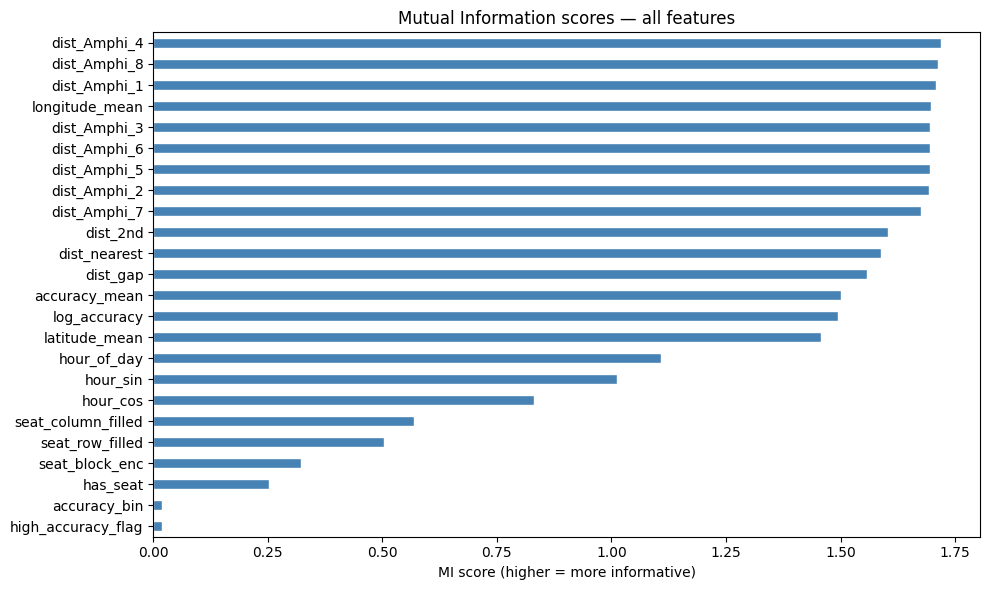


Top 10 features:
dist_Amphi_4      1.7185
dist_Amphi_8      1.7134
dist_Amphi_1      1.7094
longitude_mean    1.6982
dist_Amphi_3      1.6953
dist_Amphi_6      1.6950
dist_Amphi_5      1.6944
dist_Amphi_2      1.6920
dist_Amphi_7      1.6753
dist_2nd          1.6025


In [19]:
CANDIDATE_FEATURES = (
    dist_cols +
    ['dist_nearest', 'dist_2nd', 'dist_gap',
     'log_accuracy', 'accuracy_bin', 'high_accuracy_flag',
     'has_seat', 'seat_block_enc', 'seat_row_filled', 'seat_column_filled',
     'hour_of_day', 'hour_sin', 'hour_cos',
     'latitude_mean', 'longitude_mean', 'accuracy_mean']
)

X_mi = train[CANDIDATE_FEATURES].fillna(-1)
y_mi = train['label_enc']

mi_scores = mutual_info_classif(X_mi, y_mi, discrete_features=False, random_state=42)
mi_df = pd.Series(mi_scores, index=CANDIDATE_FEATURES).sort_values(ascending=False)

fig, ax = plt.subplots(figsize=(10, 6))
mi_df.plot(kind='barh', ax=ax, color='steelblue', edgecolor='white')
ax.invert_yaxis()
ax.set_title('Mutual Information scores — all features')
ax.set_xlabel('MI score (higher = more informative)')
plt.tight_layout()
plt.savefig('../results/mutual_information.png', dpi=120)
plt.show()

print('\nTop 10 features:')
print(mi_df.head(10).round(4).to_string())

## 9. Class imbalance reminder

Imbalance ratio is **22:1** (Amphi 2 = 2258 vs Amphi 7 = 103).  
This has to be handled at training time — feature engineering doesn't fix it.

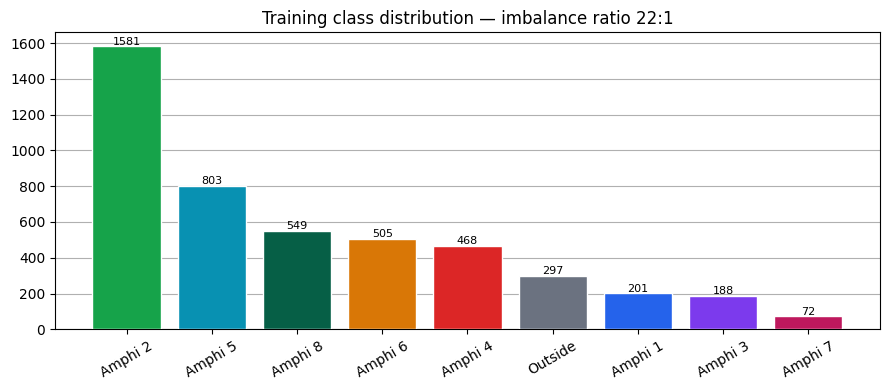

Imbalance ratio: 22.0x
→ Use class_weight="balanced" in your classifier (or SMOTE on training set only)


In [20]:
AMPHI_COLORS = {
    'Amphi 1': '#2563EB', 'Amphi 2': '#16A34A', 'Amphi 3': '#7C3AED',
    'Amphi 4': '#DC2626', 'Amphi 5': '#0891B2', 'Amphi 6': '#D97706',
    'Amphi 7': '#BE185D', 'Amphi 8': '#065F46', 'Outside': '#6B7280',
}

counts = train[TARGET_COL].value_counts()
colors = [AMPHI_COLORS[l] for l in counts.index]

fig, ax = plt.subplots(figsize=(9, 4))
bars = ax.bar(counts.index, counts.values, color=colors, edgecolor='white', zorder=3)
ax.yaxis.grid(True, zorder=0)
for bar, v in zip(bars, counts.values):
    ax.text(bar.get_x() + bar.get_width()/2, v + 10,
            str(v), ha='center', fontsize=8)
ax.set_title('Training class distribution — imbalance ratio 22:1')
ax.tick_params(axis='x', rotation=30)
plt.tight_layout()
plt.savefig('../results/class_distribution_fe.png', dpi=120)
plt.show()

ratio = counts.max() / counts.min()
print(f'Imbalance ratio: {ratio:.1f}x')
print('→ Use class_weight="balanced" in your classifier (or SMOTE on training set only)')

## 10. Final feature set definition

In [21]:
DISTANCE_FEATURES = dist_cols + ['dist_nearest', 'dist_2nd', 'dist_gap']

GPS_QUALITY_FEATURES = [
    'log_accuracy', 'accuracy_bin', 'high_accuracy_flag'
    # log_variance and sample_count_clipped dropped — constant / near-constant
]

# day_of_week and is_weekend excluded — they encode collection schedule, not real signal
TEMPORAL_FEATURES = ['hour_of_day', 'hour_sin', 'hour_cos']

SEAT_FEATURES = [
    'has_seat', 'seat_block_enc', 'seat_row_filled', 'seat_column_filled'
]

RAW_GPS = ['latitude_mean', 'longitude_mean', 'accuracy_mean']
# gps_variance excluded — constant 0 for this dataset

ALL_FEATURES = DISTANCE_FEATURES + GPS_QUALITY_FEATURES + TEMPORAL_FEATURES + SEAT_FEATURES + RAW_GPS

print(f'Distance features:    {len(DISTANCE_FEATURES)}')
print(f'GPS quality features: {len(GPS_QUALITY_FEATURES)}')
print(f'Temporal features:    {len(TEMPORAL_FEATURES)}')
print(f'Seat features:        {len(SEAT_FEATURES)}')
print(f'Raw GPS:              {len(RAW_GPS)}')
print(f'TOTAL:                {len(ALL_FEATURES)}')


Distance features:    11
GPS quality features: 3
Temporal features:    3
Seat features:        4
Raw GPS:              3
TOTAL:                24


## 11. Save engineered datasets

In [22]:
train.to_csv(PROCESSED / 'train_fe.csv', index=False)
val.to_csv(PROCESSED   / 'val_fe.csv',   index=False)
test.to_csv(PROCESSED  / 'test_fe.csv',  index=False)

feature_config = {
    'distance_features':     DISTANCE_FEATURES,
    'gps_quality_features':  GPS_QUALITY_FEATURES,
    'temporal_features':     TEMPORAL_FEATURES,
    'seat_features':         SEAT_FEATURES,
    'raw_gps':               RAW_GPS,
    'all_features':          ALL_FEATURES,
    'target_col':            'label_enc',
    'target_col_str':        TARGET_COL,
}
(PROCESSED / 'feature_cols.json').write_text(json.dumps(feature_config, indent=2))

print('Saved:')
for f in ['train_fe.csv', 'val_fe.csv', 'test_fe.csv', 'feature_cols.json', 'label_map.json', 'centroids.json']:
    print(f'  data/processed/{f}')
print(f'\nFinal train shape: {train.shape}')

Saved:
  data/processed/train_fe.csv
  data/processed/val_fe.csv
  data/processed/test_fe.csv
  data/processed/feature_cols.json
  data/processed/label_map.json
  data/processed/centroids.json

Final train shape: (4664, 49)


## Features to scale 


In [ ]:
NEVER_SCALE = {
    'id', 'year', 'label_enc',           
    'is_outside',                         
    'has_seat', 'high_accuracy_flag',       
    'accuracy_bin',                         
    'hour_of_day',                          
    'seat_block_enc', 'seat_zone_id',        
}


SCALING_FEATURES = [
    col for col in ALL_FEATURES
    if col in train.columns
    and col not in NEVER_SCALE
    and train[col].dtype in ('float64', 'float32', 'int64', 'int32')
    and train[col].std() > 1e-6
]

print(f'Scaling {len(SCALING_FEATURES)} features:')
for f in SCALING_FEATURES:
    print(f'  {f}')

scaler = StandardScaler()
scaler.fit(train[SCALING_FEATURES])

train_fe_scaled = train.copy()
val_fe_scaled   = val.copy()
test_fe_scaled  = test.copy()

train_fe_scaled[SCALING_FEATURES] = scaler.transform(train[SCALING_FEATURES])
val_fe_scaled[SCALING_FEATURES]   = scaler.transform(val[SCALING_FEATURES])
test_fe_scaled[SCALING_FEATURES]  = scaler.transform(test[SCALING_FEATURES])

train_fe_scaled.to_csv(PROCESSED / 'train_fe_scaled.csv', index=False)
val_fe_scaled.to_csv(PROCESSED   / 'val_fe_scaled.csv',   index=False)
test_fe_scaled.to_csv(PROCESSED  / 'test_fe_scaled.csv',  index=False)

import joblib
joblib.dump(scaler, PROCESSED / 'scaler_fe.pkl')

mean_ok = abs(train_fe_scaled[SCALING_FEATURES].mean().mean()) < 0.01
std_ok  = abs(train_fe_scaled[SCALING_FEATURES].std().mean() - 1) < 0.05
print(f'\nSanity — mean≈0: {mean_ok}  |  std≈1: {std_ok}')
print(f'Output shape: {train_fe_scaled.shape}  (should match train_fe.csv)')


Scaling 19 features:
  dist_Amphi_1
  dist_Amphi_2
  dist_Amphi_3
  dist_Amphi_4
  dist_Amphi_5
  dist_Amphi_6
  dist_Amphi_7
  dist_Amphi_8
  dist_nearest
  dist_2nd
  dist_gap
  log_accuracy
  hour_sin
  hour_cos
  seat_row_filled
  seat_column_filled
  latitude_mean
  longitude_mean
  accuracy_mean

Sanity — mean≈0: True  |  std≈1: True
Output shape: (4664, 49)  (should match train_fe.csv)
